# Contextual Compression Retriever

RAG(Retrieval-Augmented Generation) 시스템에서 **문맥 압축(Contextual Compression)** 을 활용한 검색 프로세스를 수행하는 경우, 정보의 밀도를 높여 생성 모델의 성능을 극대화할 수 있다.

**1. 토큰 효율성 및 비용 절감**

기존 RAG는 검색된 문서 전체를 LLM에 전달한다. 하지만 문서 내에는 질문과 무관한 노이즈가 포함된 경우가 많다. 문맥 압축을 사용하면 질문에 핵심적인 부분만 추출하여 전달하므로, LLM 입력 토큰 수를 획기적으로 줄일 수 있다. 이는 API 호출 비용 절감으로 이어진다.

**2. 'Lost in the Middle' 현상 방지**

LLM은 입력 컨텍스트가 너무 길어지면 문서의 앞부분과 뒷부분에만 집중하고 중간 내용을 간과하는 경향이 있다. 압축된 인덱스를 사용해 관련성 높은 핵심 정보만 정제하여 전달하면, 모델이 문맥을 더 정확하게 파악하고 답변의 질을 높일 수 있다.

**3. 검색 정확도(Precision) 향상**

일반적인 벡터 검색은 의미적으로 유사한 '청크'를 가져오지만, 해당 청크 안에도 불필요한 문장이 섞여 있을 수 있다. 문맥 압축기는 검색된 결과 내에서 질문과 직접적으로 관련된 문구만 재구성하거나 필터링하므로, 최종 답변 생성에 필요한 정보의 순도(Purity)가 높아진다.

**4. 다양한 문서의 통합 활용 가능**

토큰 제한 때문에 평소라면 3\~5개의 문서만 참고할 수 있었다면, 압축을 통해 문서당 길이를 줄임으로써 10\~20개의 다양한 출처로부터 정보를 수집해 전달할 수 있다. 이는 답변의 다각적인 측면을 보완하는 데 유리하다.

**구성 방식의 차이**

| 구분 | 일반적인 RAG | 문맥 압축 RAG |
| --- | --- | --- |
| **전달 내용** | 검색된 원문 청크 전체 | 질문에 최적화된 핵심 요약/추출문 |
| **LLM 부담** | 노이즈 분별 필요 (부담 높음) | 정제된 정보 기반 (부담 낮음) |
| **추론 속도** | 긴 컨텍스트로 인해 상대적 느림 | 짧고 핵심적인 컨텍스트로 빠름 |

문맥 압축 인덱스를 운영할 때는 압축 과정(Filtering/Summarizing)에서 발생하는 추가적인 연산 비용과 검색 성능 사이의 트레이드오프를 고려해야 한다.

In [3]:
%pip install langchain-classic -Uqqq

Note: you may need to restart the kernel to use updated packages.


In [4]:
from dotenv import load_dotenv
import os

load_dotenv()
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')
os.environ['PINECONE_API_KEY'] = os.getenv('PINECONE_API_KEY')
os.environ['COHERE_API_KEY'] = os.getenv('COHERE_API_KEY')

os.environ['LANGSMITH_TRACING'] = 'true'
os.environ['LANGSMITH_ENDPOINT'] = 'https://api.smith.langchain.com'
os.environ['LANGSMITH_PROJECT'] = 'skn34-langchain'
os.environ['LANGSMITH_API_KEY'] = os.getenv('LANGSMITH_API_KEY')

In [5]:
import pandas as pd

document_df = pd.read_csv('documents.csv')
queries_df = pd.read_csv('queries.csv')

In [6]:
from langchain_openai import OpenAIEmbeddings
from langchain_pinecone import PineconeVectorStore

embeddings = OpenAIEmbeddings(model='text-embedding-3-small')  # 1536차원 임베딩 모델

vector_store = PineconeVectorStore(
    index_name = 'ir',  # 연결할 index명
    embedding = embeddings  # 사용할 임베딩 함수 (연결할 인덱스 차원과 임베딩 차원이 같아야 함)
)

### LLM 기반 문맥 압축 검색기
- 검색된 문서를 대상으로 LLM이 사용자 질문과 관계없는 문서를 제거해준다.

In [9]:
# ContextualCompressionRetriever : 검색 결과를 받아 압축해주는 검색기
from langchain_classic.retrievers import ContextualCompressionRetriever  
from langchain_classic.retrievers.document_compressors import LLMChainExtractor  # LLM 기반 문맥 추출기
from langchain.chat_models import init_chat_model

base_retriever = vector_store.as_retriever()  # 기본 검색기
llm = init_chat_model('gpt-5.6-luna')
compressor = LLMChainExtractor.from_llm(llm)  # LLM 기반 추출기

# 검색 + 압축을 결합한 문맥압축 리트리버
compression_retriever = ContextualCompressionRetriever(
    base_compressor=compressor,  # 검색할 문서를 압축할 컴프레서
    base_retriever=base_retriever  # 후보 문서를 가져올 검색기
)

compression_retriever는 검색된 문서들 중에서 질문과 관련된 핵심 문맥만 LLM이 추출/압축한 형태로 반환

## 검색성능 평가

**평가지표 설명**

* **Precision\@k**: 상위 k개의 검색 결과 중에 진짜 필요한 문서가 얼마나 있는지를 측정한다.
  - 예컨대 k=5일 때, 결과 5개 중 관련 문서가 2개면 Precision\@5 = 2/5 = 0.4다.

* **Recall\@k**: 전체 관련 문서 중에서 상위 k개 안에 얼마나 많이 들어왔는지를 본다.
  - 예컨대 전체 관련 문서가 4개이고, 그중 3개가 상위 5개 안에 들어오면 Recall\@5 = 3/4 = 0.75다.


* **MRR (Mean Reciprocal Rank)**:
  사용자가 제시한 여러 질의에서, 각 질의별로 “첫 번째 관련 문서”가 나온 순위의 역수를 구한 뒤 평균낸 것이다.
  **예시**

  * 질의 A: 첫 관련 문서가 2위 → RR = 1/2 = 0.5
  * 질의 B: 첫 관련 문서가 3위 → RR = 1/3 ≈ 0.333
  * 질의 C: 첫 관련 문서가 1위 → RR = 1/1 = 1
  * 이 세 질의의 MRR = (0.5 + 0.333 + 1) / 3 ≈ 0.611

* **AP (Average Precision)**:
  한 질의 결과 리스트를 순서대로 훑어가며, 관련 문서를 만날 때마다 그 시점까지의 Precision을 계산한 뒤, 관련 문서 개수로 나눈 값이다.
  **예시** (관련 문서 3개가 있고, 순위 2, 4, 5위에 위치한 경우)

  1. 2위에서 첫 관련 문서 발견 → Precision\@2 = 1/2 = 0.50
  2. 4위에서 두 번째 관련 문서 발견 → Precision\@4 = 2/4 = 0.50
  3. 5위에서 세 번째 관련 문서 발견 → Precision\@5 = 3/5 = 0.60
     AP = (0.50 + 0.50 + 0.60) / 3 ≈ 0.533

In [10]:
from langchain_openai import OpenAIEmbeddings
from langchain_pinecone import PineconeVectorStore

embeddings = OpenAIEmbeddings(model='text-embedding-3-small')  # 1536차원 임베딩 모델

# 벡터스토어 연결
vector_store = PineconeVectorStore(
    index_name = 'ir',  # 연결할 index명
    embedding = embeddings  # 사용할 임베딩 함수 (연결할 인덱스 차원과 임베딩 차원이 같아야 함)
)
import numpy as np 

def parse_relevant(relevant_str) -> dict[str, int]:
    """
    참조문서 답안 문자열을 dict로 파싱하는 함수

    relevant_str = "D1=3;D4=1;D30=1" -> {'D1': 3, 'D4': 1, 'D30': 1}
    """
    pairs = relevant_str.split(';')  # ';' 기준으로 분리
    rel_dict = {}  # {doc_id: grade, ...}
    for pair in pairs:
        doc_id, grade = pair.split('=')  # '=' 기준으로 분리
        rel_dict[doc_id] = int(grade)  # {doc_id: grade, ...}  # grade는 int형으로 변환해 값으로써 넣어줌
    return rel_dict

# 예측 결과와 실제 정답을 비교해서 평가지표를 계산하는 함수
def compute_metrics(predicted, relevant_dict, k=5) -> tuple[float, float, float, float]:
    # Precision@k
    hits = sum([1 for doc in predicted[:k] if doc in relevant_dict])  # top_k 개 적중 개수
    predicted = hits / k  # 정밀도 = 맞춘 갯수 / 전체 갯수

    # Recall@k
    total_relevant = len(relevant_dict)  # 전체 관련 문서 수 
    recall = hits / total_relevant if total_relevant > 0 else 0  # 재현율 = 관련 문서 맞춘 수

    # MRR 예측치 중 첫 관련문서 순위 점수
    rr = 0   # 관련 문서 수 
    # 전체 랭킹에서 첫번째 적중된 것을 찾음
    for idx, doc in enumerate(predicted):
        if doc in relevant_dict:
            rr = 1 / (idx + 1)  # 첫 적중 순위 역수
            break  # 첫 번째 적중 rr 반영 후 반복문 탈출

    # AP (MAP를 위한 사전 계산)
    num_correct = 0  # 현재까지의 적중 횟수
    precisions = []  # 적중시의 precisions
    for idx, doc in enumerate(predicted[:k]):  # top-k 범위에서
        if doc in relevant_dict:
            num_correct += 1  # 적중시 1 누적
            precisions.append(num_correct / (idx + 1))  # 현재 시점의 precisions 기록
    ap = np.mean(precisions) if precisions else 0  # precisions 평균치 사용, 없으면 0

    return precisions, recall, rr, ap

# 여러 쿼리에 대한 평균 성능지표 계산하는 함수
def evaluate_all(method_results, queries_df, k=5):
    prec_list, rec_list, rr_list, ap_list = [], [], [], []  # 지표별 결과 저장

    for idx, row in queries_df.iterrows():
        qid = row['query_id']  # 쿼리 ID
        relevant_dict = parse_relevant(row['relevant_doc_ids'])  # 정답 dict 파싱
        predicted = method_results[qid]  # 해당 쿼리의 예측 랭킹
        p, r, rr, ap = compute_metrics(predicted, relevant_dict, k)  # 지표 계산
        prec_list.append(p)
        rec_list.append(r)
        rr_list.append(rr)
        ap_list.append(ap)

    return{
        'P@k': np.mean(prec_list),  # 쿼리 평균 Precision@k
        'R@k': np.mean(rec_list),  # 쿼리 평균 Recall@k
        'MRR': np.mean(rr_list),  # 쿼리 평균 MRR
        'MAP': np.mean(ap_list)  # 쿼리 평균 MAP
    }

def compute_metrics(predicted, relevant_dict, k=5) -> tuple[float, float, float, float]:
    # 1. Precision@k (단일 float 값)
    hits = sum([1 for doc in predicted[:k] if doc in relevant_dict])
    precision = hits / k

    # 2. Recall@k
    total_relevant = len(relevant_dict)
    recall = hits / total_relevant if total_relevant > 0 else 0

    # 3. MRR
    rr = 0
    for idx, doc in enumerate(predicted):
        if doc in relevant_dict:
            rr = 1 / (idx + 1)
            break

    # 4. AP (Average Precision)
    num_correct = 0
    prec_at_hits = []
    for idx, doc in enumerate(predicted[:k]):
        if doc in relevant_dict:
            num_correct += 1
            prec_at_hits.append(num_correct / (idx + 1))
    ap = np.mean(prec_at_hits) if prec_at_hits else 0.0

    # 주의: 첫 번째 반환값을 리스트(prec_at_hits)가 아닌 단일 float(precision)으로 반환합니다.
    return precision, recall, rr, ap

# 여러 쿼리에 대한 평균 성능지표 계산하는 함수
def evaluate_all(method_results, queries_df, k=5):
    prec_list, rec_list, rr_list, ap_list = [], [], [], []  # 지표별 결과 저장

    for idx, row in queries_df.iterrows():
        qid = row['query_id']  # 쿼리 ID
        relevant_dict = parse_relevant(row['relevant_doc_ids'])  # 정답 dict 파싱
        predicted = method_results[qid]  # 해당 쿼리의 예측 랭킹
        p, r, rr, ap = compute_metrics(predicted, relevant_dict, k)  # 지표 계산
        prec_list.append(p)
        rec_list.append(r)
        rr_list.append(rr)
        ap_list.append(ap)

    return{
        'P@k': np.mean(prec_list),  # 쿼리 평균 Precision@k
        'R@k': np.mean(rec_list),  # 쿼리 평균 Recall@k
        'MRR': np.mean(rr_list),  # 쿼리 평균 MRR
        'MAP': np.mean(ap_list)  # 쿼리 평균 MAP
    }

In [ ]:
from tqdm.auto import tqdm

original_results = {}  # {qid: {doc_id: content, ...}, ...}
compressed_results = {}  # {qid: {doc_id: content, ...}, ...}
top_k = 5

for idx, row in tqdm(queries_df.iterrows()):
    qid = row['query_id']
    query_text = row['query_text']

    # 원본 벡터 서치
    docs = vector_store.similarity_search(query_text, k=top_k)
    original_results[qid] = {doc.metadata['doc_id']: doc.page_content for doc in docs}

for idx, row in tqdm(queries_df.iterrows()):
    qid = row['query_id']
    query_text = row['query_text']

    # 쿼리별 문맥 압축 검색
    docs = compression_retriever.invoke(query_text, k=top_k)
    compressed_results[qid] = {doc.metadata['doc_id'] for doc in docs}

0it [00:00, ?it/s]

0it [00:00, ?it/s]

In [16]:
from pprint import pprint

qid = 'Q10'
# qid에 해당하는 쿼리 텍스트 추출
query_text = queries_df[queries_df['query_id'] == qid]['query_text'].values[0]
print(f'Query : {query_text}')

pprint(original_results[qid])
pprint(compressed_results[qid])

Query : 한국 축구 대표팀 2002년 한일 월드컵 4강 진출 이유
{'D10': '한국 축구 대표팀은 2002 한일 월드컵 4강 진출, 2012 런던 올림픽 동메달 ...',
 'D15': '가야금은 한국 전통 현악기로, 12개의 줄을 가진 칠현금(七絃琴) 계열 악기입니다....',
 'D25': '2025년 한국 정부는 “AI 국가전략 2.0”을 발표하며, 인공지능 기술 연구·개...',
 'D3': '걸스데이는 2010년 데뷔한 대한민국의 4인조 걸그룹으로, 대표곡으로는 “Somet...',
 'D4': '세종대왕(1397~1450)은 훈민정음을 창제하여 한글을 보급한 조선의 4대 임금입...'}
{'D10'}


compressed_results는 결과 5개를 그대로 반환하지 않고, 관련 내용이 없으면 관련 문서로 취급하지 않음.

In [17]:
original_results_ = {qid: [doc_id for doc_id in original_results[qid]] for qid in original_results}
compressed_results_ = {qid: [doc_id for doc_id in compressed_results[qid]] for qid in compressed_results}

original_metrics = evaluate_all(original_results_, queries_df, k=5)
compressed_metrics = evaluate_all(compressed_results_, queries_df, k=5) 

In [18]:
metrics_df = pd.DataFrame({
    'Metrics': ['P@5', 'R@5', 'MRR', 'MAP'],  # 지표 이름
    'Original': [original_metrics['P@k'], original_metrics['R@k'], original_metrics['MRR'], original_metrics['MAP']],
    'Compressed': [compressed_metrics['P@k'], compressed_metrics['R@k'], compressed_metrics['MRR'], compressed_metrics['MAP']]
})
metrics_df

,Metrics,Original,Compressed
0,P@5,0.246667,0.186667
1,R@5,0.888889,0.722222
2,MRR,0.950000,0.811111
3,MAP,0.920556,0.811111


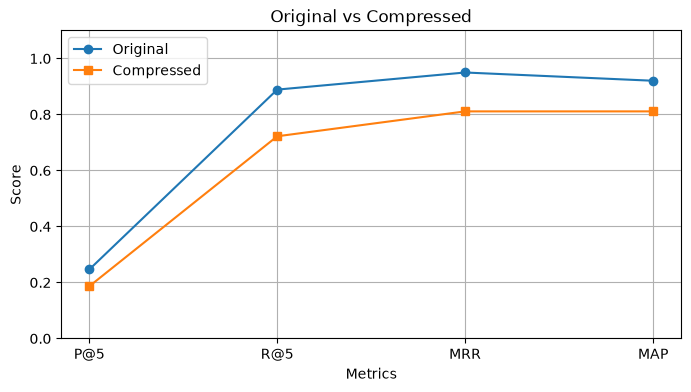

In [19]:
import matplotlib.pyplot as plt

metrics = ['P@5', 'R@5', 'MRR', 'MAP']
original_vals = [original_metrics['P@k'], original_metrics['R@k'], original_metrics['MRR'], original_metrics['MAP']]
compressed_vals = [compressed_metrics['P@k'], compressed_metrics['R@k'], compressed_metrics['MRR'], compressed_metrics['MAP']]

x = range(len(metrics))  # 0~3

plt.figure(figsize=(8, 4))
plt.plot(x, original_vals, marker='o', label='Original')
plt.plot(x, compressed_vals, marker='s', label='Compressed')
plt.xticks(x, metrics)  # x축 눈금은 0~3 -> 지표명
plt.ylim(0, 1.1)
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Original vs Compressed')
plt.legend()
plt.grid()
plt.show()

## Compressed Retrieval

### 정의
Compressed Retrieval은 검색된 문서의 전체 내용을 그대로 사용하는 것이 아니라,  
**질문(Query)과 직접적으로 관련된 핵심 문맥만을 추출하여 반환하는 검색 방식**이다.

---

### 처리 흐름
1. **Dense Retrieval**을 통해 관련 문서 후보를 검색한다.
2. **LLM 기반 Compression 단계**에서 각 문서로부터 질문과 관련된 부분만 추출한다.
3. 압축된 문맥을 최종 검색 결과로 활용한다.

---

### 핵심 특징
- Dense Retrieval 자체는 요약이나 압축을 수행하지 않는다.
- 문맥 압축은 **검색 이후 단계**에서 LLM이 수행한다.
- 문서를 사전에 요약해두는 방식이 아니라, **쿼리 기준으로 동적 추출**이 이루어진다.

---

### 장점
- 불필요한 문맥 제거로 **토큰 사용량 감소**
- LLM 응답 속도 개선
- RAG 환경에서 **환각(Hallucination) 감소**
- 대규모 문서 검색 시 효율적

---

### 단점
- 압축 과정에서 일부 정보 손실 가능
- LLM 호출로 인한 추가 비용 발생
- Recall 지표가 소폭 감소할 수 있음

---

### 결론
> Compressed Retrieval은 검색 품질을 유지하면서  
> **LLM 입력 문맥을 효율적으로 최적화하기 위한 후처리 검색 기법**이다.